# Cluster Summary — iGEM

Cluster-level summaries for iGEM teams topic model using year-based normalization (no citation metrics).

Output:
- `assets/reports/cluster_summary_igem.tsv`

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
np.random.seed(SEED)

ASSETS = os.path.join('..', 'assets')
MODELS = os.path.join(ASSETS, 'topic_models')
REPORTS = os.path.join(ASSETS, 'reports')
os.makedirs(REPORTS, exist_ok=True)

In [2]:
# Load iGEM metadata and topic model outputs
igem = pd.read_csv(os.path.join(ASSETS, 'igem.txt'), sep='\t')
teams_doc_topics = pd.read_csv(os.path.join(MODELS, 'teams_doc_topics.txt'), sep='\t')
teams_topic_names = pd.read_csv(os.path.join(MODELS, 'teams_topic_names.txt'), sep='\t')

igem['Year_y'] = pd.to_numeric(igem['Year_y'], errors='coerce')
igem = igem.rename(columns={'Year_y': 'year'})

# Merge topic assignments and names
igem_topics = igem.merge(teams_doc_topics, on='UT', how='left')
igem_topics = igem_topics.merge(teams_topic_names[['topic', 'global_name']], on='topic', how='left')

print(f"iGEM rows: {len(igem_topics):,}")
print(f"Topics: {igem_topics['topic'].nunique()} (incl. outlier -1)")
igem_topics[['UT', 'year', 'topic', 'global_name']].head(3)

iGEM rows: 4,548
Topics: 161 (incl. outlier -1)


,UT,year,topic,global_name
0,5260,2024,24,Space Biotechnologies for Sustainability
1,5794,2025,114,Diagnostic & Forensic Synthetic Biology
2,4831,2023,106,Mercury Bioremediation & Detection


In [3]:
# Compute year-normalized metrics by topic (exclude outlier -1)
igem_valid = igem_topics[(igem_topics['topic'] >= 0) & igem_topics['year'].notna()].copy()

max_year = int(igem_valid['year'].max())
igem_valid['is_recent'] = (igem_valid['year'] >= max_year - 4).astype(int)
igem_valid['year_rank'] = igem_valid['year'].rank(pct=True)

cluster_summary_igem = igem_valid.groupby('topic').agg(
    n_teams=('UT', 'nunique'),
    n_records=('UT', 'size'),
    avg_year=('year', 'mean'),
    median_year=('year', 'median'),
    year_std=('year', 'std'),
    min_year=('year', 'min'),
    max_year=('year', 'max'),
    price_index=('is_recent', 'mean'),
    avg_year_rank=('year_rank', 'mean'),
).reset_index()

cluster_summary_igem = cluster_summary_igem.merge(
    teams_topic_names[['topic', 'global_name']], on='topic', how='left'
)

if 'Countries' in igem_valid.columns:
    country_counts = (
        igem_valid.groupby('topic')['Countries']
        .apply(lambda x: x.fillna('').replace('', np.nan).dropna().nunique())
        .reset_index(name='n_countries')
    )
    cluster_summary_igem = cluster_summary_igem.merge(country_counts, on='topic', how='left')

out_igem = os.path.join(REPORTS, 'cluster_summary_igem.tsv')
cluster_summary_igem.to_csv(out_igem, sep='\t', index=False)

print(f"Clusters: {len(cluster_summary_igem)}")
print(f"Price Index window: {max_year-4}-{max_year}")
print(f"Saved: {out_igem}")
cluster_summary_igem.sort_values(['n_teams', 'avg_year_rank'], ascending=[False, False]).head(15)

Clusters: 161
Price Index window: 2021-2025
Saved: ../assets/reports/cluster_summary_igem.tsv


,topic,n_teams,n_records,avg_year,median_year,year_std,min_year,max_year,price_index,avg_year_rank,global_name,n_countries
0,0,104,104,2021.317308,2022.0,2.956856,2013,2025,0.701923,0.670216,Synthetic Diagnostics & Biosensing Technologies,25
1,1,101,101,2015.435644,2016.0,4.583483,2009,2025,0.168317,0.311838,Light-Controlled Biological Systems,25
2,2,91,91,2017.912088,2018.0,4.468776,2009,2025,0.351648,0.453641,Synthetic Microbial Detection & Biofilm Manage...,24
4,4,78,78,2020.461538,2022.0,4.142564,2009,2025,0.589744,0.621540,Synthetic Therapeutics for Cancer & Diseases,20
6,6,78,78,2019.782051,2020.0,3.910185,2009,2025,0.474359,0.571729,Synthetic Blood & Metabolic Biosystems,22
3,3,74,74,2020.824324,2021.5,3.582140,2012,2025,0.621622,0.640877,Synthetic Plastic Degradation & Recycling,20
13,13,65,65,2015.953846,2016.0,4.671826,2009,2025,0.169231,0.341934,Cellular & Bioproduction Engineering,20
7,7,63,63,2019.190476,2019.0,3.783910,2011,2025,0.365079,0.529155,Genetic Control & Diagnostic Circuits,15
5,5,62,62,2020.951613,2022.0,3.923145,2009,2025,0.645161,0.655231,Microbial Diagnostic & Therapeutic Platforms,14
10,10,62,62,2017.483871,2017.0,4.404699,2009,2025,0.322581,0.425316,Synthetic Environmental & Resource Solutions,16


Most recent topics (avg_year):
 topic                                     global_name  n_teams    avg_year  median_year  price_index  avg_year_rank
   158                 Eye Disease & Vision Biosystems        9 2022.222222       2023.0     0.777778       0.735268
    27        Environmental Pollution & Sustainability       40 2022.025000       2023.0     0.700000       0.730321
   133            Sleep & Mental Health Bioengineering       15 2021.866667       2024.0     0.733333       0.712995
   113              Probiotic & Microbial Therapeutics       21 2021.809524       2022.0     0.666667       0.709061
    43               Gut-Brain Synthetic Interventions       29 2021.724138       2022.0     0.827586       0.693704
    52            Pollution Detection & Bioremediation       26 2021.653846       2023.0     0.692308       0.697809
    58            Neurodegenerative Disease Strategies       28 2021.357143       2022.0     0.714286       0.673773
     0 Synthetic Diagnostics & Bi

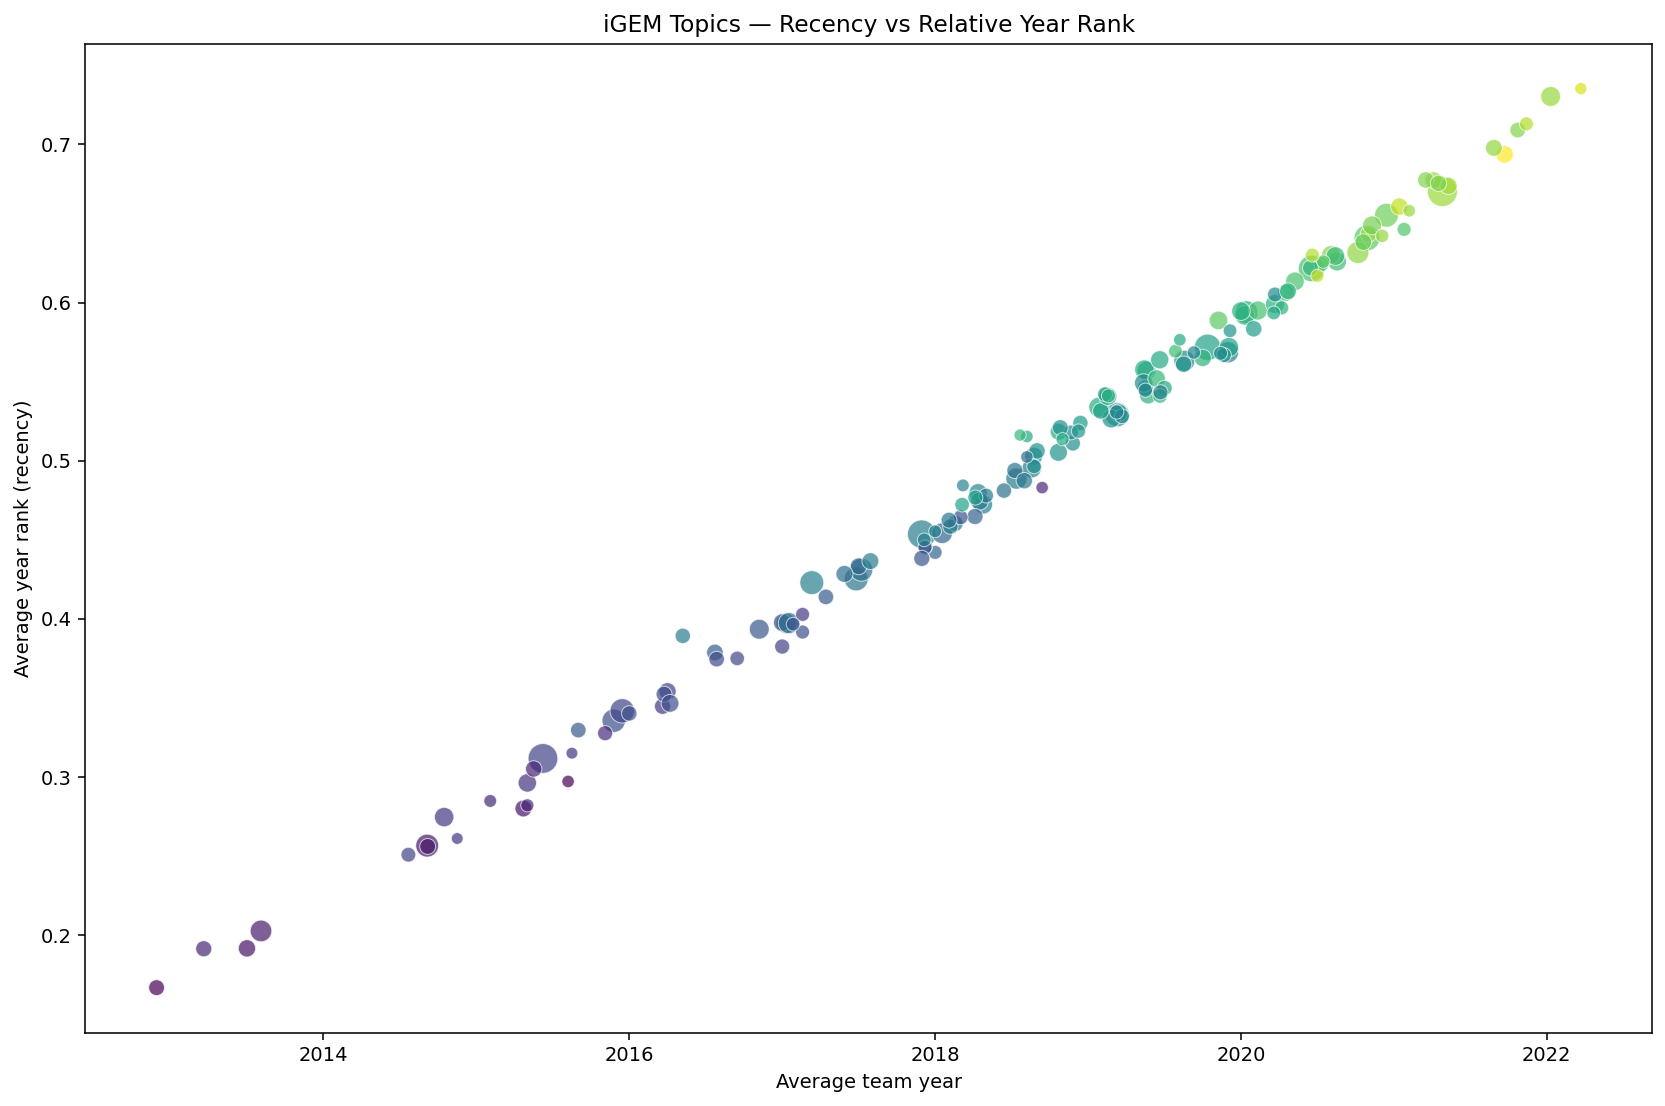

In [4]:
# Compact views: most recent and largest iGEM topics
print('Most recent topics (avg_year):')
display_cols = ['topic', 'global_name', 'n_teams', 'avg_year', 'median_year', 'price_index', 'avg_year_rank']
print(cluster_summary_igem.sort_values('avg_year', ascending=False)[display_cols].head(10).to_string(index=False))

print('\nLargest topics by teams:')
print(cluster_summary_igem.sort_values('n_teams', ascending=False)[display_cols].head(10).to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 8), dpi=140)
sizes = 20 + 220 * (cluster_summary_igem['n_teams'] / cluster_summary_igem['n_teams'].max())
ax.scatter(
    cluster_summary_igem['avg_year'],
    cluster_summary_igem['avg_year_rank'],
    s=sizes,
    alpha=0.7,
    edgecolors='white',
    linewidth=0.5,
    c=cluster_summary_igem['price_index'],
    cmap='viridis',
)
ax.set_xlabel('Average team year')
ax.set_ylabel('Average year rank (recency)')
ax.set_title('iGEM Topics — Recency vs Relative Year Rank')
plt.tight_layout()
plt.show()